In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# https://dontpad.com/bcc-ds-02

df = pd.read_csv('https://raysonlaroca.github.io/' +
                 'teaching/data-science/datasets/iris.csv')

In [ ]:
df.head(3)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


In [ ]:
# criar uma função que gera todas as combinações

from itertools import chain, combinations

def powerset(valores):
    # powerset([1, 2, 3])
    # [(), (1), (2), (3), (1, 2), ... (1, 2, 3)]

    s = list(valores)
    return chain.from_iterable(combinations(s, r) for r in range(1, len(s)+1))

In [ ]:
list(powerset([1, 2, 3]))

[(1,), (2,), (3,), (1, 2), (1, 3), (2, 3), (1, 2, 3)]

In [ ]:
target_col = 'variety'
colunas = list(df.columns.values)
colunas.remove(target_col)

colunas

['sepal.length', 'sepal.width', 'petal.length', 'petal.width']

In [ ]:
combinacoes = list(powerset(colunas))
combinacoes

[('sepal.length',),
 ('sepal.width',),
 ('petal.length',),
 ('petal.width',),
 ('sepal.length', 'sepal.width'),
 ('sepal.length', 'petal.length'),
 ('sepal.length', 'petal.width'),
 ('sepal.width', 'petal.length'),
 ('sepal.width', 'petal.width'),
 ('petal.length', 'petal.width'),
 ('sepal.length', 'sepal.width', 'petal.length'),
 ('sepal.length', 'sepal.width', 'petal.width'),
 ('sepal.length', 'petal.length', 'petal.width'),
 ('sepal.width', 'petal.length', 'petal.width'),
 ('sepal.length', 'sepal.width', 'petal.length', 'petal.width')]

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

resultados = []

for comb in combinacoes:
    list_features = list(comb)

    # criar X e y
    X, y = df[list_features], df[target_col]

    accs_dt = []
    accs_knn = []

    # leave one out
    loo = LeaveOneOut()

    # treinar e testar os modelos
    for train_index, test_index in loo.split(X):
        # pegar os dados de treino e de teste
        X_train, X_test = X.loc[train_index], X.loc[test_index]
        y_train, y_test = y.loc[train_index], y.loc[test_index]

        # treino knn
        knn = KNeighborsClassifier(1, algorithm='brute')
        knn.fit(X_train, y_train)

        # treino DT
        dt = DecisionTreeClassifier(criterion='entropy',
                                    min_impurity_decrease=0.25,
                                    random_state=123)
        dt.fit(X_train, y_train)

        # teste knn
        y_pred_knn = knn.predict(X_test)

        # teste dt
        y_pred_dt = dt.predict(X_test)

        # medir a acurácia (0 ou 1 aqui)
        acc_knn = accuracy_score(y_test, y_pred_knn)
        acc_dt = accuracy_score(y_test, y_pred_dt)

        # salva os resultados
        accs_knn.append(acc_knn)
        accs_dt.append(acc_dt)

    # acurácia média dos 2 classificadores
    media_knn = 100.0 * sum(accs_knn) / len(accs_knn)
    media_dt = 100.0 * sum(accs_dt) / len(accs_dt)

    # mostra os resultados
    print('-' * 30)
    print(f'FEATURES: {list(comb)}')
    print(f'    DT: {media_dt:.2f}%')
    print(f'   KNN: {media_knn:.2f}%\n')


------------------------------
FEATURES: ['sepal.length']
    DT: 62.67%
   KNN: 58.67%

------------------------------
FEATURES: ['sepal.width']
    DT: 52.67%
   KNN: 48.00%

------------------------------
FEATURES: ['petal.length']
    DT: 94.00%
   KNN: 88.00%

------------------------------
FEATURES: ['petal.width']
    DT: 95.33%
   KNN: 88.00%

------------------------------
FEATURES: ['sepal.length', 'sepal.width']
    DT: 62.67%
   KNN: 70.67%

------------------------------
FEATURES: ['sepal.length', 'petal.length']
    DT: 94.00%
   KNN: 91.33%

------------------------------
FEATURES: ['sepal.length', 'petal.width']
    DT: 95.33%
   KNN: 92.67%

------------------------------
FEATURES: ['sepal.width', 'petal.length']
    DT: 94.00%
   KNN: 92.00%

------------------------------
FEATURES: ['sepal.width', 'petal.width']
    DT: 95.33%
   KNN: 92.67%

------------------------------
FEATURES: ['petal.length', 'petal.width']
    DT: 95.33%
   KNN: 96.67%

----------------------

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

In [ ]:
target_col, colunas

('variety', ['sepal.length', 'sepal.width', 'petal.length', 'petal.width'])

In [ ]:
# criar X e y novamente
X, y = df[colunas], df[target_col]

In [ ]:
# instancia os modelos
lr = LogisticRegression(max_iter=1000,
                        random_state=123)

dt = DecisionTreeClassifier(random_state=123)

In [ ]:
loo = LeaveOneOut()

In [ ]:
rfe_dt = RFECV(estimator=dt, cv=loo, scoring='accuracy')
rfe_lr = RFECV(estimator=lr, cv=loo, scoring='accuracy')

In [ ]:
rfe_dt.fit(X, y)
rfe_lr.fit(X, y)

RFECV(cv=LeaveOneOut(),
      estimator=LogisticRegression(max_iter=1000, random_state=123),
      scoring='accuracy')

In [ ]:
print('DT:')

# quantas
print(f'  # features: {rfe_dt.n_features_}')

# quais (máscara)
print(f'  máscara: {rfe_dt.support_}')

# quais
print(f'  features: {np.array(colunas)[rfe_dt.support_]}')

# ranking
print(f'  ranking: {rfe_dt.ranking_}')

print(f"  scores: {rfe_dt.cv_results_['mean_test_score']}")

DT:
  # features: 2
  máscara: [False False  True  True]
  features: ['petal.length' 'petal.width']
  ranking: [2 3 1 1]
  scores: [0.92       0.94666667 0.94666667 0.94666667]


In [ ]:
print('LR:')

# quantas
print(f'  # features: {rfe_lr.n_features_}')

# quais (máscara)
print(f'  máscara: {rfe_lr.support_}')

# quais
print(f'  features: {np.array(colunas)[rfe_lr.support_]}')

# ranking
print(f'  ranking: {rfe_lr.ranking_}')

print(f"  scores: {rfe_lr.cv_results_['mean_test_score']}")

LR:
  # features: 3
  máscara: [False  True  True  True]
  features: ['sepal.width' 'petal.length' 'petal.width']
  ranking: [2 1 1 1]
  scores: [0.95333333 0.96       0.96666667 0.96666667]


In [ ]:
from sklearn.feature_selection import SelectKBest # Filter

In [ ]:
skb = SelectKBest(k='all')
skb.fit(X, y)

SelectKBest(k='all')

In [ ]:
skb.scores_

array([ 119.26450218,   49.16004009, 1180.16118225,  960.0071468 ])

In [ ]:
scores = pd.Series(data=skb.scores_,
                   index=X.columns.values)
scores

,0
sepal.length,119.264502
sepal.width,49.160040
petal.length,1180.161182
petal.width,960.007147


<Axes: >

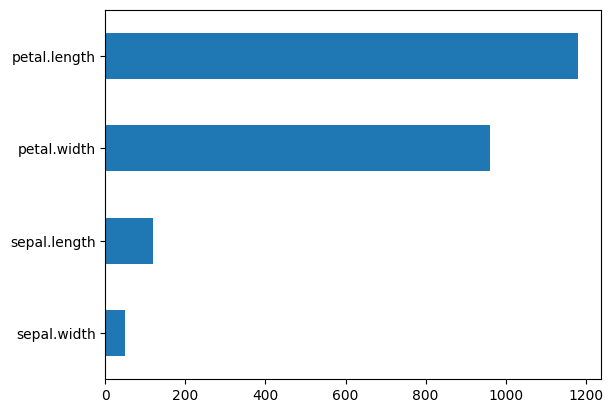

In [ ]:
scores.sort_values().plot(kind='barh')

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=123)
rf = RandomForestClassifier(random_state=123)

In [ ]:
dt.fit(X, y)
rf.fit(X, y)

RandomForestClassifier(random_state=123)

In [ ]:
scores_dt = dt.feature_importances_
scores_rf = rf.feature_importances_

In [ ]:
scores_dt = pd.Series(scores_dt, index=X.columns.values)
scores_rf = pd.Series(scores_rf, index=X.columns.values)


In [ ]:
scores_dt

,0
sepal.length,0.026667
sepal.width,0.000000
petal.length,0.550723
petal.width,0.422611


[Text(0.5, 0.9166666666666666, 'petal.length <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = Setosa'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = Setosa'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'petal.width <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = Versicolor'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'petal.length <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = Versicolor'),
 Text(0.15384615384615385, 0.4166666666666667, 'petal.width <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]\nclass = Versicolor'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]\nclass = Versicolor'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = Virginica'),
 Text(0.46153846153846156, 0.4166666666666667, 'petal.width <

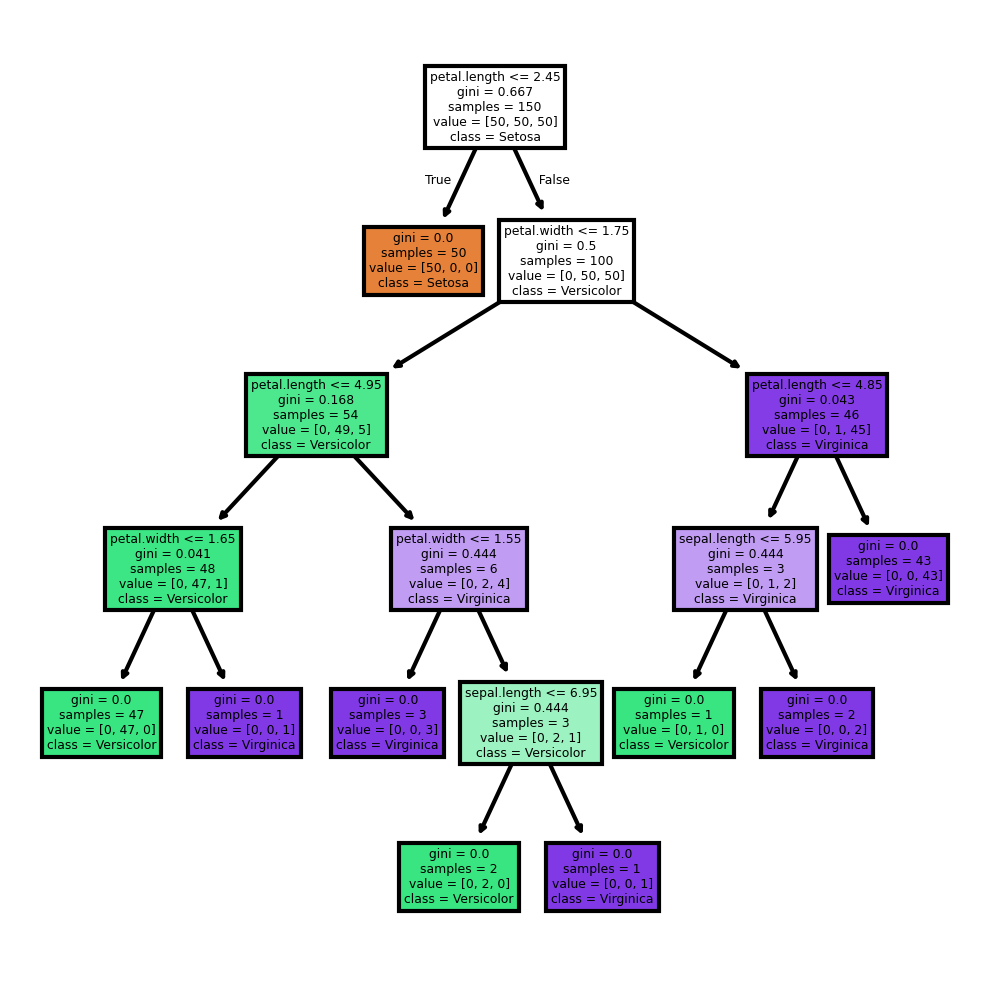

In [ ]:
from sklearn import tree

plt.subplots(nrows=1, ncols=1, figsize=(4,4), dpi=300)
tree.plot_tree(dt, feature_names=X.columns.values,
               class_names=y.unique(), filled=True)